<a href="https://colab.research.google.com/github/SamShinwari/Advanced-AI-Bootcamp-2026/blob/main/Project_2_Word%20Frequency%20Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

##Project 2: Word Frequency Analysis

In this project, we'll analyze the most common and least common words in the news dataset. This helps us understand the vocabulary and identify important terms before building ML models.

##Objectives

You will learn how to:

*  Count word frequencies
*  Find the most common words
*  Find the least common words
*  Calculate vocabulary size
*  Plot the top words
*  Generate a Word Cloud

## Library Imports
This cell imports essential libraries for data handling, word counting, and visualization.

In [43]:
import pandas as pd
from collections import Counter
import matplotlib.pyplot as plt
from wordcloud import WordCloud
from google.colab import drive

## Mount Google Drive
Mounting Google Drive to access the dataset file.

In [44]:
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


## Load Dataset
Loading the BBC news dataset from Drive into a pandas DataFrame.

In [45]:
file_path = '/content/drive/MyDrive/Colab Notebooks/bbc_dataset.csv'
df = pd.read_csv(file_path)
df.head()

,title,pubDate,guid,link,description
0,Ukraine: Angry Zelensky vows to punish Russian...,"Mon, 07 Mar 2022 08:01:56 GMT",https://www.bbc.co.uk/news/world-europe-60638042,https://www.bbc.co.uk/news/world-europe-606380...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Sun, 06 Mar 2022 22:49:58 GMT",https://www.bbc.co.uk/news/world-europe-60641873,https://www.bbc.co.uk/news/world-europe-606418...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',"Mon, 07 Mar 2022 00:14:42 GMT",https://www.bbc.co.uk/news/business-60623941,https://www.bbc.co.uk/news/business-60623941?a...,One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,"Mon, 07 Mar 2022 00:05:40 GMT",https://www.bbc.co.uk/news/uk-60579079,https://www.bbc.co.uk/news/uk-60579079?at_medi...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,"Mon, 07 Mar 2022 08:15:53 GMT",https://www.bbc.co.uk/news/business-60642786,https://www.bbc.co.uk/news/business-60642786?a...,Consumers are feeling the impact of higher ene...


## Clean Data
Removing rows with missing titles and duplicate entries.

##remove null rows,duplicate rows

This cell performs initial data cleaning. It drops rows where the 'title' column has missing values and then removes any duplicate rows based on the 'title' column. Finally, `reset_index(drop=True)` re-indexes the DataFrame.

In [46]:
df = df.dropna(subset=["title"])
df = df.drop_duplicates(subset=["title"])
df = df.reset_index(drop=True)

## Drop Unnecessary Columns
Removing columns not needed for word frequency analysis.

###drop extra column

In [47]:
df = df.drop(columns=['guid', 'link','pubDate'])
df.head()

,title,description
0,Ukraine: Angry Zelensky vows to punish Russian...,The Ukrainian president says the country will ...
1,War in Ukraine: Taking cover in a town under a...,"Jeremy Bowen was on the frontline in Irpin, as..."
2,Ukraine war 'catastrophic for global food',One of the world's biggest fertiliser firms sa...
3,Manchester Arena bombing: Saffie Roussos's par...,The parents of the Manchester Arena bombing's ...
4,Ukraine conflict: Oil price soars to highest l...,Consumers are feeling the impact of higher ene...


## Concatenate Text
Combining all article descriptions into a single string for analysis.

In [48]:
all_text = " ".join(df["description"])
print(all_text[0:50])

The Ukrainian president says the country will not 


## Tokenize Words
Splitting the combined text into individual words.

In [49]:
words = all_text.split()

print(words[:15])

['The', 'Ukrainian', 'president', 'says', 'the', 'country', 'will', 'not', 'forgive', 'or', 'forget', 'those', 'who', 'murder', 'its']


## Calculate Word Frequencies
Counting the occurrences of each word.

In [50]:
word_freq = Counter(words)

print(word_freq)

Counter({'the': 28562, 'to': 15557, 'a': 13816, 'of': 13804, 'in': 13569, 'and': 9724, 'The': 7870, 'on': 5793, 'is': 5773, 'for': 5537, 'at': 4465, 'as': 4220, 'are': 3916, 'after': 3527, 'with': 3523, 'says': 3367, 'his': 3314, 'was': 3096, 'from': 3054, 'by': 2950, 'has': 2910, 'their': 2643, 'will': 2502, 'have': 2391, 'an': 2153, 'A': 2127, 'but': 2081, 'be': 2064, 'he': 1961, 'her': 1874, 'over': 1867, 'been': 1852, 'it': 1686, 'BBC': 1519, 'first': 1511, '-': 1495, 'they': 1400, 'England': 1381, 'who': 1379, 'World': 1294, 'people': 1267, 'about': 1248, 'that': 1230, 'were': 1226, 'not': 1174, 'Cup': 1162, 'new': 1114, 'against': 1094, 'say': 1041, 'out': 1031, 'League': 1025, 'its': 1020, 'being': 965, 'more': 959, 'win': 950, 'she': 944, 'UK': 883, 'up': 865, 'one': 863, 'into': 863, 'two': 860, 'US': 830, 'could': 827, 'Manchester': 818, 'than': 754, 'how': 749, 'this': 748, 'some': 713, 'what': 703, 'had': 701, 'which': 675, 'former': 643, 'years': 616, 'when': 612, 'during'

## Identify Top 20 Words
Extracting the 20 most frequently occurring words.

In [51]:
top20 = word_freq.most_common(20)

print(top20)

[('the', 28562), ('to', 15557), ('a', 13816), ('of', 13804), ('in', 13569), ('and', 9724), ('The', 7870), ('on', 5793), ('is', 5773), ('for', 5537), ('at', 4465), ('as', 4220), ('are', 3916), ('after', 3527), ('with', 3523), ('says', 3367), ('his', 3314), ('was', 3096), ('from', 3054), ('by', 2950)]


## Create Top 20 DataFrame
Converting the top 20 words into a pandas DataFrame.

In [52]:
freq_df = pd.DataFrame(top20, columns=["Word", "Frequency"])

print(freq_df)

     Word  Frequency
0     the      28562
1      to      15557
2       a      13816
3      of      13804
4      in      13569
5     and       9724
6     The       7870
7      on       5793
8      is       5773
9     for       5537
10     at       4465
11     as       4220
12    are       3916
13  after       3527
14   with       3523
15   says       3367
16    his       3314
17    was       3096
18   from       3054
19     by       2950


## Visualize Top 20 Words
Plotting a bar chart of the 20 most frequent words.

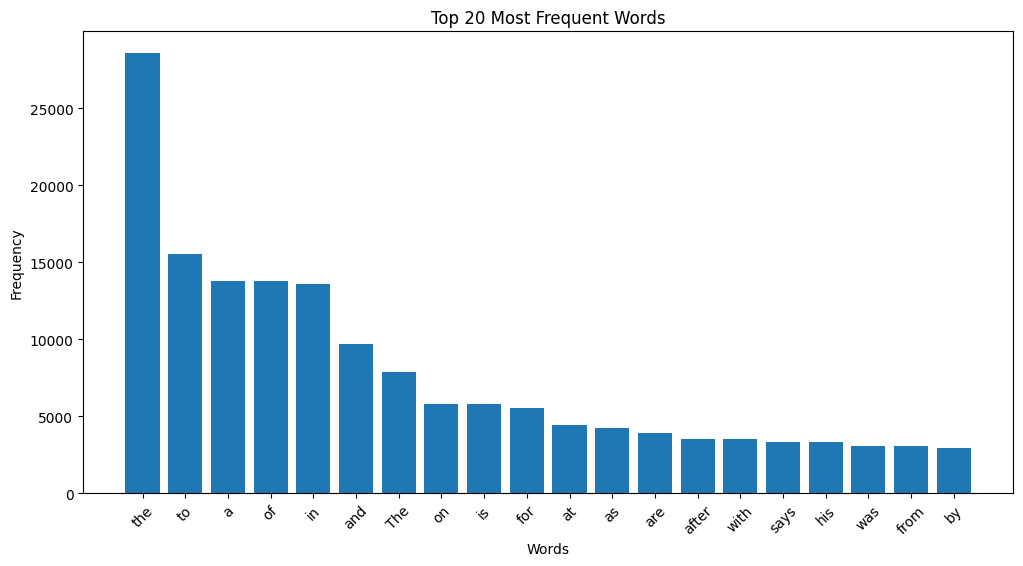

In [53]:
plt.figure(figsize=(12,6))

plt.bar(freq_df["Word"], freq_df["Frequency"])

plt.title("Top 20 Most Frequent Words")
plt.xlabel("Words")
plt.ylabel("Frequency")

plt.xticks(rotation=45)

plt.show()

## Generate Word Cloud
Creating a visual representation of word frequencies.

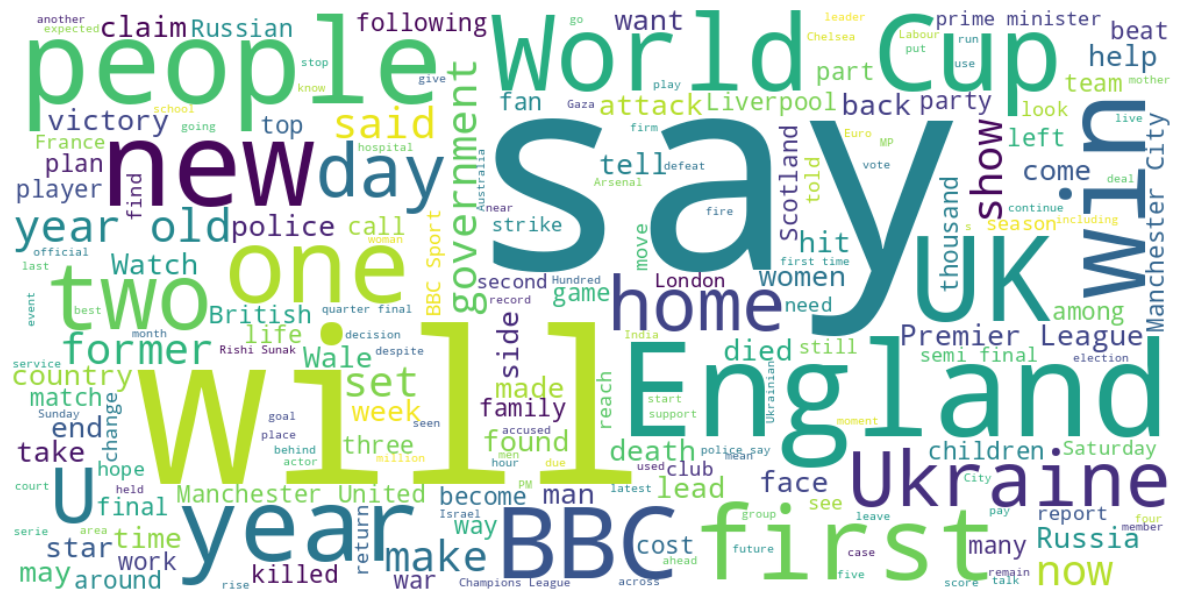

In [54]:
wordcloud = WordCloud(
    width=1000,
    height=500,
    background_color="white"
).generate(all_text)

plt.figure(figsize=(15,8))
plt.imshow(wordcloud, interpolation="bilinear")
plt.axis("off")
plt.show()

## Calculate Vocabulary Size
Determining the total number of unique words.

In [55]:
vocab = len(word_freq)

print("Vocabulary Size:", vocab)

Vocabulary Size: 54471


## Count Total Words
Calculating the total count of all words.

In [56]:
print("Total Words:", len(words))

Total Words: 595684


## Find Most Common Word
Identifying the single most frequent word.

In [57]:
most_common = word_freq.most_common(1)

print(most_common)

[('the', 28562)]


## Find Rare Words
Listing words that appear only once in the dataset.

In [58]:
rare_words = [word for word, count in word_freq.items() if count == 1]

print("Number of Rare Words:", len(rare_words))

print(rare_words[:10])

Number of Rare Words: 29058
["bombing's", 'PMs,', 'oligarchs.', '"surging', 'capacity"', '5,500', 'granted.', 'cities,', 'Vladivostok', 'messaged']


## Full Frequency Distribution
Creating a DataFrame for the complete word frequency list.

In [59]:
frequency_distribution = pd.DataFrame(
    word_freq.items(),
    columns=["Word","Frequency"]
)

frequency_distribution = frequency_distribution.sort_values(
    by="Frequency",
    ascending=False
)

frequency_distribution.head(10)

,Word,Frequency
4,the,28562
31,to,15557
42,a,13816
34,of,13804
21,in,13569
68,and,9724
0,The,7870
19,on,5793
74,is,5773
232,for,5537


## Save Word Frequencies
Exporting the word frequency distribution to a CSV file.

In [60]:
frequency_distribution.to_csv(
    "word_frequency.csv",
    index=False
)

print("Saved Successfully")

Saved Successfully
